# Neural Network Workflow Example -- Pneumonia Detection

# Data Background
**Pneumonia is an inflammatory condition of the lung affecting primarily the small air sacs known as alveoli.Symptoms typically include some combination of productive or dry cough, chest pain, fever and difficulty breathing. The severity of the condition is variable. Pneumonia is usually caused by infection with viruses or bacteria and less commonly by other microorganisms, certain medications or conditions such as autoimmune diseases.Risk factors include cystic fibrosis, chronic obstructive pulmonary disease (COPD), asthma, diabetes, heart failure, a history of smoking, a poor ability to cough such as following a stroke and a weak immune system. Diagnosis is often based on symptoms and physical examination. Chest X-ray, blood tests, and culture of the sputum may help confirm the diagnosis.The disease may be classified by where it was acquired, such as community- or hospital-acquired or healthcare-associated pneumonia.**

In [ ]:
# Update this path to your chest_xray dataset root (contains train/, test/, val/)
DATA_ROOT = '/scratch/vp91/zxw900/applied_ml/data/chest_xray'

# Importing the necessary libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Description of the Pneumonia Dataset
**The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).
Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children's Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients' routine clinical care.
For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.**

In [6]:
labels = ['PNEUMONIA', 'NORMAL']

size_counts = {}
for label in labels:
    path = os.path.join(DATA_ROOT, 'train', label)
    for img_name in os.listdir(path)[:50]:
        img_arr = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
        if img_arr is not None:
            h, w = img_arr.shape[:2]
            size_counts[(h, w)] = size_counts.get((h, w), 0) + 1

print('Original image sizes (height x width) in train set:')
for (h, w), count in sorted(size_counts.items(), key=lambda x: -x[1]):
    print(f'  {h} x {w}: {count} images')

if size_counts:
    heights = [h for (h, w) in size_counts for _ in range(size_counts[(h, w)])]
    widths = [w for (h, w) in size_counts for _ in range(size_counts[(h, w)])]
    print(f'\nAll train images — height range: {min(heights)}–{max(heights)}, width range: {min(widths)}–{max(widths)}')

Original image sizes (height x width) in train set:
  1295 x 1692: 1 images
  752 x 920: 1 images
  767 x 1218: 1 images
  568 x 904: 1 images
  615 x 1040: 1 images
  568 x 992: 1 images
  1008 x 1320: 1 images
  1056 x 1464: 1 images
  648 x 1016: 1 images
  188 x 499: 1 images
  464 x 712: 1 images
  672 x 1216: 1 images
  1024 x 1328: 1 images
  584 x 864: 1 images
  768 x 1080: 1 images
  1144 x 1272: 1 images
  960 x 1512: 1 images
  544 x 920: 1 images
  816 x 1160: 1 images
  840 x 1400: 1 images
  848 x 1008: 1 images
  992 x 1440: 1 images
  1008 x 1224: 1 images
  408 x 668: 1 images
  800 x 1160: 1 images
  656 x 968: 1 images
  736 x 1112: 1 images
  1184 x 1408: 1 images
  1208 x 1480: 1 images
  1168 x 1440: 1 images
  1152 x 1328: 1 images
  592 x 1272: 1 images
  947 x 1450: 1 images
  560 x 904: 1 images
  998 x 1562: 1 images
  768 x 1048: 1 images
  536 x 1096: 1 images
  680 x 1120: 1 images
  1264 x 1424: 1 images
  680 x 896: 1 images
  459 x 749: 1 images
  456 

In [7]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path)[:50]:
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return np.array(data, dtype=object)

# Loading the Dataset

In [8]:
train = get_training_data(os.path.join(DATA_ROOT, 'train'))
test = get_training_data(os.path.join(DATA_ROOT, 'test'))
val = get_training_data(os.path.join(DATA_ROOT, 'val'))

# Feature engineering & data cleaning
## Considerations
- Dirty data
- Data to numbers
- Data bias from real world.

## Techniques 
- Cleaning - nulls, text tags
- Encoding - One-hot, ...
- Scaling 
- Calibration 
- Rotation, mirroring etc


Exoplanet data EDA, Scale, Augmentation


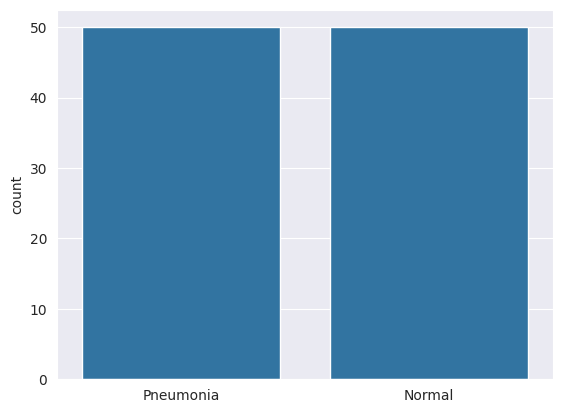

In [9]:
l = []
for i in train:
    if i[1] == 0:
        l.append('Pneumonia')
    else:
        l.append('Normal')
sns.set_style('darkgrid')
sns.countplot(x=l)
plt.show()

**The data seems imbalanced. To increase the no. of training examples, we will use data augmentation**

**Previewing the images of both the classes**

Text(0.5, 1.0, 'NORMAL')

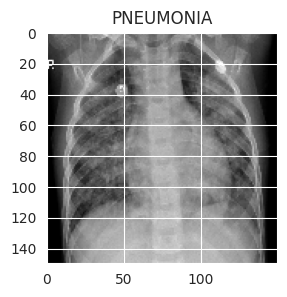

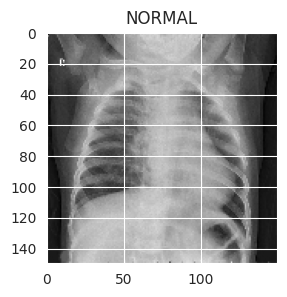

In [11]:
plt.figure(figsize=(3, 3))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(3, 3))
plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])

In [12]:
x_train, y_train = [], []
x_val, y_val = [], []
x_test, y_test = [], []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

**We perform a grayscale normalization to reduce the effect of illumination's differences. Moreover the CNN converges faster on [0..1] data than on [0..255].**

In [13]:
x_train = np.array(x_train, dtype=np.float32) / 255.0
x_val = np.array(x_val, dtype=np.float32) / 255.0
x_test = np.array(x_test, dtype=np.float32) / 255.0

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Data Augmentation
**In order to avoid overfitting problem, we need to expand artificially our dataset. We can make your existing dataset even larger. The idea is to alter the training data with small transformations to reproduce the variations.
Approaches that alter the training data in ways that change the array representation while keeping the label the same are known as data augmentation techniques. Some popular augmentations people use are grayscales, horizontal flips, vertical flips, random crops, color jitters, translations, rotations, and much more.
By applying just a couple of these transformations to our training data, we can easily double or triple the number of training examples and create a very robust model.**

In [14]:
class PneumoniaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).unsqueeze(0)
        return image, torch.tensor(label, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

train_dataset = PneumoniaDataset(x_train, y_train, transform=train_transform)
# Match original notebook: validation also uses augmentation during training
val_dataset = PneumoniaDataset(x_val, y_val, transform=train_transform)
test_dataset = PneumoniaDataset(x_test, y_test, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

For the data augmentation, i choosed to :
1. Randomly rotate some training images by 30 degrees
2. Randomly Zoom by 20% some training images
3. Randomly shift images horizontally by 10% of the width
4. Randomly shift images vertically by 10% of the height
5. Randomly flip images horizontally.
Once our model is ready, we fit the training dataset.

# Training the Model

In [15]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.Dropout(0.1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.Dropout(0.2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.Dropout(0.2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PneumoniaCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.RMSprop(model.parameters())
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2, min_lr=1e-6)

print(model)
print(f'Using device: {device}')

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Dropout(p=0.1, inplace=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1

In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total


NUM_EPOCHS = 12
history = {'accuracy': [], 'loss': [], 'val_accuracy': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    scheduler.step(val_acc)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} - '
        f'loss: {train_loss:.4f} - acc: {train_acc:.4f} - '
        f'val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}'
    )

Epoch 1/12 - loss: 337.8151 - acc: 0.4500 - val_loss: 47.9997 - val_acc: 0.5000
Epoch 2/12 - loss: 22.1604 - acc: 0.5200 - val_loss: 2.6251 - val_acc: 0.5000
Epoch 3/12 - loss: 6.7338 - acc: 0.4800 - val_loss: 0.6988 - val_acc: 0.5000
Epoch 4/12 - loss: 1.5525 - acc: 0.5500 - val_loss: 0.6980 - val_acc: 0.5000
Epoch 5/12 - loss: 1.6539 - acc: 0.5600 - val_loss: 0.7412 - val_acc: 0.5000
Epoch 6/12 - loss: 2.1198 - acc: 0.4700 - val_loss: 0.8094 - val_acc: 0.5000
Epoch 7/12 - loss: 1.3469 - acc: 0.5300 - val_loss: 0.8205 - val_acc: 0.5000
Epoch 8/12 - loss: 1.6019 - acc: 0.5400 - val_loss: 0.8094 - val_acc: 0.5000
Epoch 9/12 - loss: 1.4788 - acc: 0.5400 - val_loss: 0.8050 - val_acc: 0.5000
Epoch 10/12 - loss: 1.3251 - acc: 0.4900 - val_loss: 0.6296 - val_acc: 0.6250
Epoch 11/12 - loss: 1.1646 - acc: 0.5400 - val_loss: 0.7296 - val_acc: 0.5000
Epoch 12/12 - loss: 1.5536 - acc: 0.4900 - val_loss: 0.6795 - val_acc: 0.5000


In [17]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print('Loss of the model is -', test_loss)
print('Accuracy of the model is -', test_acc * 100, '%')

Loss of the model is - 0.7931840896606446
Accuracy of the model is - 50.0 %


# Analysis after Model Training

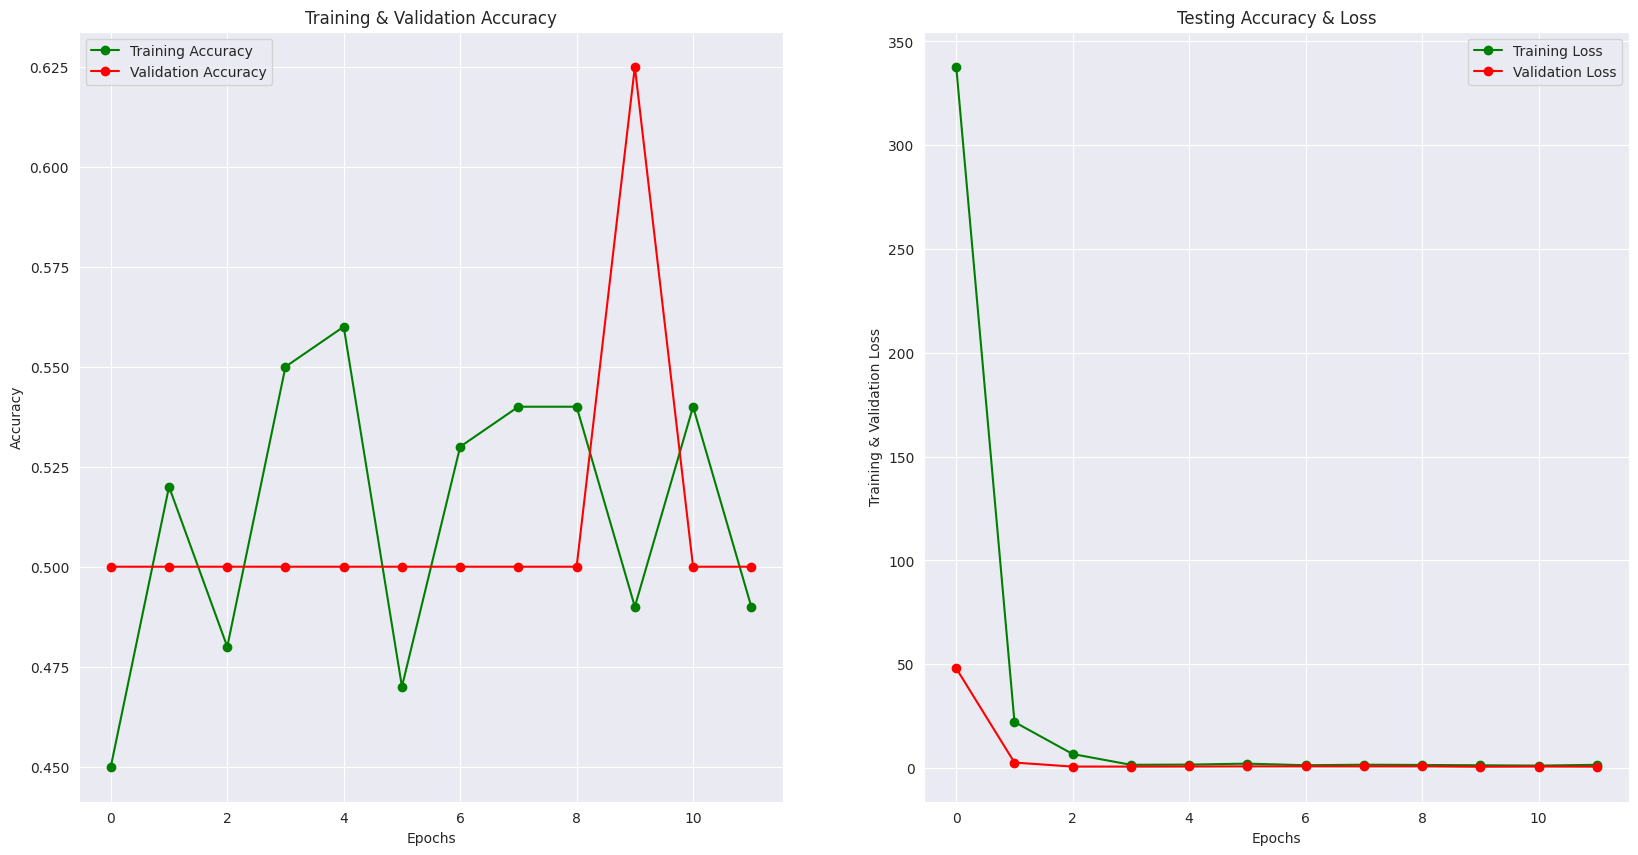

In [18]:
epochs = [i for i in range(NUM_EPOCHS)]
fig, ax = plt.subplots(1, 2)
train_acc = history['accuracy']
train_loss = history['loss']
val_acc = history['val_accuracy']
val_loss = history['val_loss']
fig.set_size_inches(20, 10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Training & Validation Loss')
plt.show()

In [19]:
model.eval()
all_preds = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).long().cpu().numpy()
        all_preds.extend(preds)

predictions = np.array(all_preds)
predictions[:15]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [20]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.50      1.00      0.67        50
   Normal (Class 1)       0.00      0.00      0.00        50

           accuracy                           0.50       100
          macro avg       0.25      0.50      0.33       100
       weighted avg       0.25      0.50      0.33       100



/scratch/vp91/applied_ml_venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/vp91/applied_ml_venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/scratch/vp91/applied_ml_venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [21]:
cm = confusion_matrix(y_test, predictions)
cm

array([[50,  0],
       [50,  0]])

In [22]:
cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])

<Axes: >

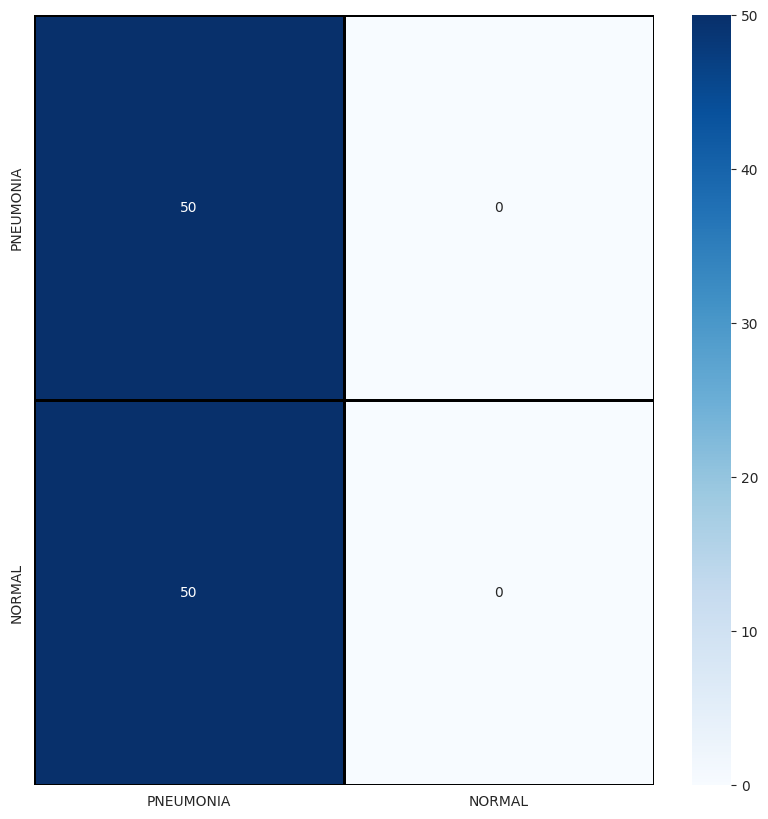

In [23]:
plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap='Blues', linecolor='black', linewidth=1, annot=True, fmt='', xticklabels=labels, yticklabels=labels)

In [24]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

**Some of the Correctly Predicted Classes**

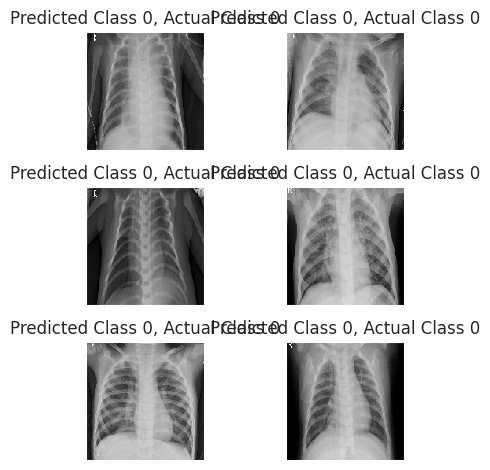

In [25]:
i = 0
for c in correct[:6]:
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150, 150), cmap='gray', interpolation='none')
    plt.title('Predicted Class {}, Actual Class {}'.format(predictions[c], int(y_test[c])))
    plt.tight_layout()
    i += 1

**Some of the Incorrectly Predicted Classes**

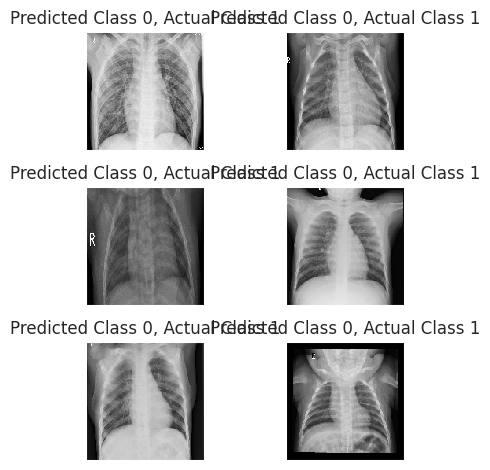

In [26]:
i = 0
for c in incorrect[:6]:
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150, 150), cmap='gray', interpolation='none')
    plt.title('Predicted Class {}, Actual Class {}'.format(predictions[c], int(y_test[c])))
    plt.tight_layout()
    i += 1